# Machine Learning Laboratory
## Lab Session 3: Data Pre-Processing
**Date:** June 30, 2026  
**Course:** Machine Learning Lab (SEM 5)  
**Topic:** Data Pre-Processing Experiments

---
### Table of Contents
1. [Experiment 1: Handling Missing Values](#Experiment-1:-Handling-Missing-Values)
2. [Experiment 2: Data Normalization and Standardization](#Experiment-2:-Data-Normalization-and-Standardization)
3. [Experiment 3: Encoding Categorical Data](#Experiment-3:-Encoding-Categorical-Data)
4. [Experiment 4: Handling Outliers](#Experiment-4:-Handling-Outliers)
5. [Experiment 5: Data Visualization for Preprocessing](#Experiment-5:-Data-Visualization-for-Preprocessing)
6. [Experiment 7: Handling Imbalanced Data](#Experiment-7:-Handling-Imbalanced-Data)
7. [Experiment 8: Data Splitting and Cross Validation](#Experiment-8:-Data-Splitting-and-Cross-Validation)


## Experiment 1: Handling Missing Values

### Aim
Create a dataset containing missing values, replace them using various imputation techniques, compare the effects of each technique, and analyze the impact of removing missing values on dataset size.

### Mathematical Formulations

#### Imputation Techniques:
1. **Mean Imputation:** Replaces missing values with the arithmetic mean of the available values.
   $$\mu = \frac{1}{N} \sum_{i=1}^{N} x_i$$
2. **Median Imputation:** Replaces missing values with the middle value of the sorted data. Useful when data has outliers.
3. **Mode Imputation:** Replaces missing values with the most frequent value. Essential for categorical variables.


In [1]:
import pandas as pd
import numpy as np

# 1. Create a dataset containing missing values
data = {
    'Feature_A': [12, 15, np.nan, 18, 22, np.nan, 25, 30, 35, 40],
    'Feature_B': [150, 160, 155, np.nan, 175, 180, np.nan, 190, 200, np.nan],
    'Feature_C': [5.1, np.nan, 5.5, 6.0, np.nan, 6.2, 6.5, 7.0, 7.2, 7.5]
}
df_missing = pd.DataFrame(data)
print("Original Dataset with Missing Values:")
print(df_missing)
print("\nMissing Value Count per Feature:")
print(df_missing.isnull().sum())

# 2. Impute missing values using Mean, Median, and Mode
print("\n--- Mean Imputed Dataset ---")
df_mean = df_missing.fillna(df_missing.mean())
print(df_mean)

print("\n--- Median Imputed Dataset ---")
df_median = df_missing.fillna(df_missing.median())
print(df_median)

print("\n--- Mode Imputed Dataset ---")
df_mode = df_missing.copy()
for col in df_mode.columns:
    df_mode[col] = df_mode[col].fillna(df_mode[col].mode()[0])
print(df_mode)

# 3. Compare statistics
print("\n--- Statistical Comparison of Feature_A Imputation ---")
comparison = pd.DataFrame({
    'Original': df_missing['Feature_A'],
    'Mean_Imputed': df_mean['Feature_A'],
    'Median_Imputed': df_median['Feature_A'],
    'Mode_Imputed': df_mode['Feature_A']
})
print(comparison.describe().loc[['mean', 'std', 'min', 'max']])

# 4. Remove missing values
print("\n--- Impact of Removing Missing Values ---")
print(f"Original size: {df_missing.shape}")
df_drop_rows = df_missing.dropna(axis=0)
print(f"Size after dropping rows: {df_drop_rows.shape}")
df_drop_cols = df_missing.dropna(axis=1)
print(f"Size after dropping columns: {df_drop_cols.shape}")


Original Dataset with Missing Values:
   Feature_A  Feature_B  Feature_C
0       12.0      150.0        5.1
1       15.0      160.0        NaN
2        NaN      155.0        5.5
3       18.0        NaN        6.0
4       22.0      175.0        NaN
5        NaN      180.0        6.2
6       25.0        NaN        6.5
7       30.0      190.0        7.0
8       35.0      200.0        7.2
9       40.0        NaN        7.5

Missing Value Count per Feature:
Feature_A    2
Feature_B    3
Feature_C    2
dtype: int64

--- Mean Imputed Dataset ---
   Feature_A   Feature_B  Feature_C
0     12.000  150.000000      5.100
1     15.000  160.000000      6.375
2     24.625  155.000000      5.500
3     18.000  172.857143      6.000
4     22.000  175.000000      6.375
5     24.625  180.000000      6.200
6     25.000  172.857143      6.500
7     30.000  190.000000      7.000
8     35.000  200.000000      7.200
9     40.000  172.857143      7.500

--- Median Imputed Dataset ---
   Feature_A  Feature_B  Fe

## Experiment 2: Data Normalization and Standardization

### Aim
Normalize a dataset using Min-Max Scaling and standardize it using Z-score normalization, then visualize the distributions before and after scaling.

### Mathematical Formulations

#### 1. Min-Max Scaling (Normalization)
Rescales features into a range of $[0, 1]$.
$$x_{\text{norm}} = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}$$

#### 2. Z-score Normalization (Standardization)
Rescales features to have a mean of $0$ and a standard deviation of $1$.
$$x_{\text{std}} = \frac{x - \mu}{\sigma}$$


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Set seed for reproducibility
np.random.seed(42)

# Generate a synthetic dataset with different scales
data_scale = {
    'Income': np.random.normal(50000, 15000, 1000),      # High value, high variance
    'Age': np.random.randint(18, 70, 1000).astype(float) # Medium range
}
df_scale = pd.DataFrame(data_scale)

# 1. Normalize using Min-Max Scaling
min_max_scaler = MinMaxScaler()
df_normalized = pd.DataFrame(
    min_max_scaler.fit_transform(df_scale),
    columns=df_scale.columns
)

# 2. Standardize using Z-score Normalization
std_scaler = StandardScaler()
df_standardized = pd.DataFrame(
    std_scaler.fit_transform(df_scale),
    columns=df_scale.columns
)

# 3. Visualize feature distributions before and after scaling
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

# Original
sns.kdeplot(data=df_scale, x='Income', ax=axes[0, 0], fill=True, color='blue')
axes[0, 0].set_title('Original Income Distribution')
sns.kdeplot(data=df_scale, x='Age', ax=axes[0, 1], fill=True, color='green')
axes[0, 1].set_title('Original Age Distribution')

# Normalized
sns.kdeplot(data=df_normalized, x='Income', ax=axes[1, 0], fill=True, color='blue')
axes[1, 0].set_title('Min-Max Normalized Income (0 to 1)')
sns.kdeplot(data=df_normalized, x='Age', ax=axes[1, 1], fill=True, color='green')
axes[1, 1].set_title('Min-Max Normalized Age (0 to 1)')

# Standardized
sns.kdeplot(data=df_standardized, x='Income', ax=axes[2, 0], fill=True, color='blue')
axes[2, 0].set_title('Z-Score Standardized Income (mean=0, std=1)')
sns.kdeplot(data=df_standardized, x='Age', ax=axes[2, 1], fill=True, color='green')
axes[2, 1].set_title('Z-Score Standardized Age (mean=0, std=1)')

plt.tight_layout()
plt.show()

# Print statistics to verify
print("Original Stats:")
print(df_scale.describe().loc[['mean', 'std', 'min', 'max']])
print("\nNormalized Stats:")
print(df_normalized.describe().loc[['mean', 'std', 'min', 'max']])
print("\nStandardized Stats:")
print(df_standardized.describe().loc[['mean', 'std', 'min', 'max']])


Original Stats:
             Income        Age
mean   50289.980837  43.080000
std    14688.239073  15.047526
min     1380.989899  18.000000
max   107790.972360  69.000000

Normalized Stats:
        Income       Age
mean  0.459628  0.491765
std   0.138034  0.295050
min   0.000000  0.000000
max   1.000000  1.000000

Standardized Stats:
            Income           Age
mean -2.478018e-16  1.065814e-16
std   1.000500e+00  1.000500e+00
min  -3.331472e+00 -1.667553e+00
max   3.916723e+00  1.723404e+00


## Experiment 3: Encoding Categorical Data

### Aim
Convert categorical variables into numerical form using Label Encoding and One-Hot Encoding, compare their outputs, and apply the encodings to a dataset with multiple categorical features.

### Concept:
- **Label Encoding:** Assigns a unique integer value to each category. Suitable for ordinal data (where categories have an inherent order).
- **One-Hot Encoding:** Creates a binary column for each category. Suitable for nominal data (no order) and prevents algorithms from assuming order.


Original Dataset with Categorical Features:
        City Experience  Salary
0     Mumbai     Junior      50
1      Delhi     Senior      90
2  Bangalore  Mid-Level      70
3     Mumbai     Junior      52
4    Chennai     Senior      95
5      Delhi  Mid-Level      75
6    Chennai     Junior      48

Label Encoded Dataset:
        City Experience  Salary  City_Label  Experience_Label
0     Mumbai     Junior      50           3                 0
1      Delhi     Senior      90           2                 2
2  Bangalore  Mid-Level      70           0                 1
3     Mumbai     Junior      52           3                 0
4    Chennai     Senior      95           1                 2
5      Delhi  Mid-Level      75           2                 1
6    Chennai     Junior      48           1                 0

One-Hot Encoded Dataset:
   Salary  City_Bangalore  ...  Experience_Mid-Level  Experience_Senior
0      50           False  ...                 False              False
1      90 

Traceback (most recent call last):
  File "/Users/hirthikbalaji/.gemini/antigravity-cli/brain/9d20fa74-bd45-49ba-a53b-bbb5ed2a5876/scratch/generate_notebooks.py", line 40, in run_cell_code
    exec(exec_code, globals_dict)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<string>", line 44, in <module>
  File "/Users/hirthikbalaji/miniconda3/lib/python3.13/site-packages/pandas/plotting/_core.py", line 1030, in __call__
    return plot_backend.plot(data, kind=kind, **kwargs)
           ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/hirthikbalaji/miniconda3/lib/python3.13/site-packages/pandas/plotting/_matplotlib/__init__.py", line 71, in plot
    plot_obj.generate()
    ~~~~~~~~~~~~~~~~~^^
  File "/Users/hirthikbalaji/miniconda3/lib/python3.13/site-packages/pandas/plotting/_matplotlib/core.py", line 499, in generate
    self._compute_plot_data()
    ~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/hirthikbalaji/miniconda3/lib/python3.13/site-packages/pandas/plotting/_matplotlib/core.py", 

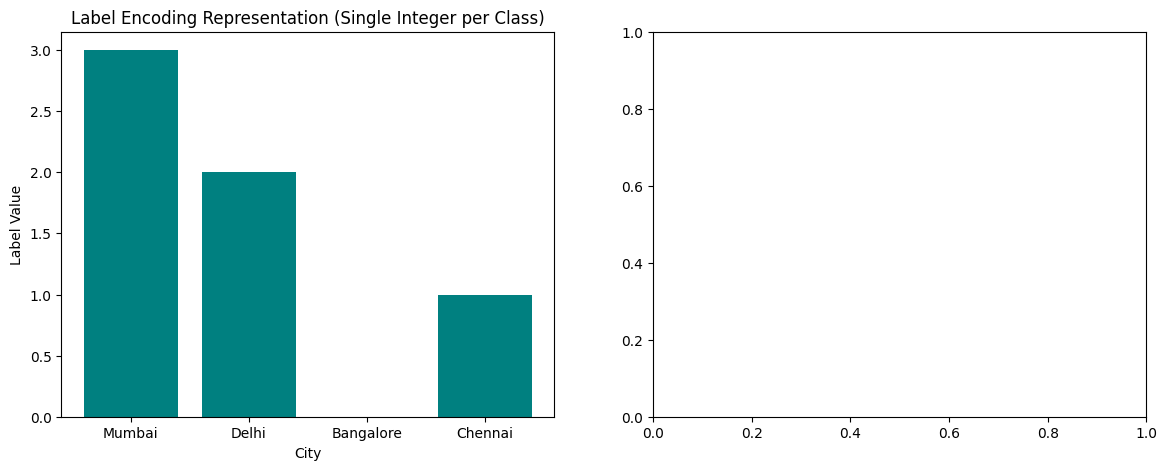

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# 1. Create a dataset containing multiple categorical features
data_cat = {
    'City': ['Mumbai', 'Delhi', 'Bangalore', 'Mumbai', 'Chennai', 'Delhi', 'Chennai'],
    'Experience': ['Junior', 'Senior', 'Mid-Level', 'Junior', 'Senior', 'Mid-Level', 'Junior'],
    'Salary': [50, 90, 70, 52, 95, 75, 48]
}
df_cat = pd.DataFrame(data_cat)
print("Original Dataset with Categorical Features:")
print(df_cat)

# A. Label Encoding (on City and Experience)
df_label = df_cat.copy()
le_city = LabelEncoder()
le_exp = LabelEncoder()

df_label['City_Label'] = le_city.fit_transform(df_label['City'])
df_label['Experience_Label'] = le_exp.fit_transform(df_label['Experience'])
print("\nLabel Encoded Dataset:")
print(df_label)

# B. One-Hot Encoding (on City and Experience)
df_ohe = pd.get_dummies(df_cat, columns=['City', 'Experience'], drop_first=False)
print("\nOne-Hot Encoded Dataset:")
print(df_ohe)

# 2. Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Label Encoding representation for City
axes[0].bar(df_label['City'], df_label['City_Label'], color='teal')
axes[0].set_title('Label Encoding Representation (Single Integer per Class)')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Label Value')

# Plot One-Hot Encoding representation for City
ohe_columns = [col for col in df_ohe.columns if col.startswith('City_')]
df_ohe_city = df_ohe[ohe_columns].drop_duplicates()
df_ohe_city.index = df_cat['City'].unique()
df_ohe_city.plot(kind='bar', ax=axes[1])
axes[1].set_title('One-Hot Encoding Representation (Binary Columns)')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Binary Value')
axes[1].legend(title='Encoded Columns')

plt.tight_layout()
plt.show()


## Experiment 4: Handling Outliers

### Aim
Detect outliers in a dataset using box plots, the Interquartile Range (IQR) method, and Z-score analysis. Remove detected outliers and analyze the performance impact on a model.

### Mathematical Formulations

#### 1. IQR Method
Lower bound and upper bound:
$$\text{IQR} = Q_3 - Q_1$$
$$\text{Lower Bound} = Q_1 - 1.5 \times \text{IQR}$$
$$\text{Upper Bound} = Q_3 + 1.5 \times \text{IQR}$$
Any data point beyond these bounds is classified as an outlier.

#### 2. Z-score Method
$$Z = \frac{x - \mu}{\sigma}$$
Typically, points with $|Z| > 3$ are considered outliers.


IQR Lower Bound: -13.62, Upper Bound: 135.10
Outliers detected by IQR: 3
        X      Y
100   6.0  180.0
101   8.0  220.0
102  24.0  -50.0

Outliers detected by Z-score (|Z| > 3): 3
        X      Y   Z_Score
100   6.0  180.0  3.888423
101   8.0  220.0  5.207045
102  24.0  -50.0 -3.693654

--- Statistics Comparison ---
With Outliers Y:
mean     62.045874
std      30.334693
min     -50.000000
max     220.000000
Name: Y, dtype: float64

Without Outliers Y:
mean     60.407250
std      20.639836
min      26.068789
max     100.491200
Name: Y, dtype: float64

--- Model Performance Comparison ---
Model with Outliers: R^2 = 0.2218, MSE = 709.18
Model without Outliers: R^2 = 0.9522, MSE = 20.16


Traceback (most recent call last):
  File "/Users/hirthikbalaji/.gemini/antigravity-cli/brain/9d20fa74-bd45-49ba-a53b-bbb5ed2a5876/scratch/generate_notebooks.py", line 40, in run_cell_code
    exec(exec_code, globals_dict)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<string>", line 78, in <module>
  File "/Users/hirthikbalaji/miniconda3/lib/python3.13/site-packages/matplotlib/pyplot.py", line 3838, in plot
    return gca().plot(
           ~~~~~~~~~~^
        *args,
        ^^^^^^
    ...<3 lines>...
        **kwargs,
        ^^^^^^^^^
    )
    ^
  File "/Users/hirthikbalaji/miniconda3/lib/python3.13/site-packages/matplotlib/axes/_axes.py", line 1777, in plot
    lines = [*self._get_lines(self, *args, data=data, **kwargs)]
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/hirthikbalaji/miniconda3/lib/python3.13/site-packages/matplotlib/axes/_base.py", line 297, in __call__
    yield from self._plot_args(
               ~~~~~~~~~~~~~~~^
        axes, this, k

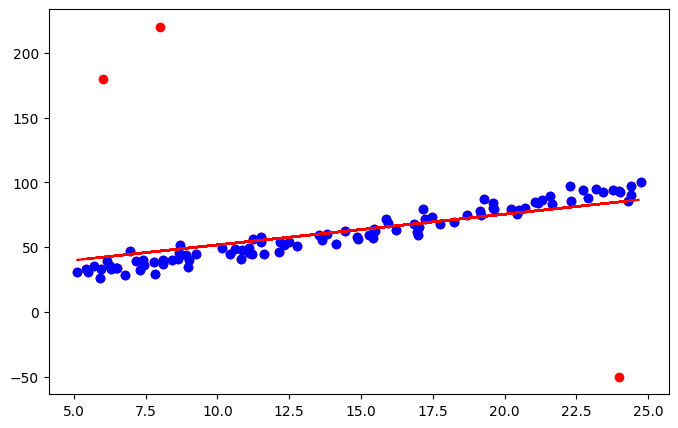

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Generate data with outliers
np.random.seed(42)
x = np.random.uniform(5, 25, 100)
y = 3.5 * x + 10 + np.random.normal(0, 5, 100)

# Add outlier points
x = np.append(x, [6, 8, 24])
y = np.append(y, [180, 220, -50])

df_outlier = pd.DataFrame({'X': x, 'Y': y})

# 1. Detect outliers using box plots
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.boxplot(df_outlier['Y'])
plt.title('Box Plot of Target Y')

plt.subplot(1, 2, 2)
plt.scatter(df_outlier['X'], df_outlier['Y'], color='blue', alpha=0.7)
plt.title('Scatter Plot (X vs Y)')
plt.show()

# 2. Identify outliers using the IQR method (for Y)
Q1 = df_outlier['Y'].quantile(0.25)
Q3 = df_outlier['Y'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_outliers = df_outlier[(df_outlier['Y'] < lower_bound) | (df_outlier['Y'] > upper_bound)]
print(f"IQR Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
print(f"Outliers detected by IQR: {len(iqr_outliers)}")
print(iqr_outliers)

# 3. Detect outliers using Z-score analysis (for Y)
mean_y = df_outlier['Y'].mean()
std_y = df_outlier['Y'].std()
df_outlier['Z_Score'] = (df_outlier['Y'] - mean_y) / std_y
z_outliers = df_outlier[df_outlier['Z_Score'].abs() > 3]
print(f"\nOutliers detected by Z-score (|Z| > 3): {len(z_outliers)}")
print(z_outliers)

# 4. Remove outliers (using IQR) and compare statistics
df_clean = df_outlier[(df_outlier['Y'] >= lower_bound) & (df_outlier['Y'] <= upper_bound)]
print("\n--- Statistics Comparison ---")
print("With Outliers Y:")
print(df_outlier['Y'].describe().loc[['mean', 'std', 'min', 'max']])
print("\nWithout Outliers Y:")
print(df_clean['Y'].describe().loc[['mean', 'std', 'min', 'max']])

# 5. Study the impact of outliers on ML Model (Linear Regression)
# Model with Outliers
X_raw = df_outlier[['X']]
y_raw = df_outlier['Y']
model_raw = LinearRegression().fit(X_raw, y_raw)
pred_raw = model_raw.predict(X_raw)

# Model without Outliers
X_clean = df_clean[['X']]
y_clean = df_clean['Y']
model_clean = LinearRegression().fit(X_clean, y_clean)
pred_clean = model_clean.predict(X_clean)

print("\n--- Model Performance Comparison ---")
print(f"Model with Outliers: R^2 = {r2_score(y_raw, pred_raw):.4f}, MSE = {mean_squared_error(y_raw, pred_raw):.2f}")
print(f"Model without Outliers: R^2 = {r2_score(y_clean, pred_clean):.4f}, MSE = {mean_squared_error(y_clean, pred_clean):.2f}")

# Visualize regression lines
plt.figure(figsize=(8, 5))
plt.scatter(df_outlier['X'], df_outlier['Y'], color='red', label='Outliers/Data')
plt.scatter(df_clean['X'], df_clean['Y'], color='blue', label='Inliers')
plt.plot(df_outlier['X'], pred_raw, color='red', linestyle='--', label='Regression with Outliers')
plt.plot(df_clean['X'], model_clean.predict(X_raw), color='blue', linestyle='-', label='Regression without Outliers')
plt.legend()
plt.title('Impact of Outliers on Linear Regression')
plt.show()


## Experiment 5: Data Visualization for Preprocessing

### Aim
Visualize feature distributions using histograms, plot pairwise relationships using scatter plots, generate a correlation heatmap, identify skewed features, and suggest preprocessing based on visual analysis.

### Concept:
- **Skewness:** A measure of the asymmetry of the probability distribution of a real-valued random variable.
- **Log Transformation:** Reduces right-skewness to help numerical features follow a normal distribution.
  $$x_{\text{transformed}} = \log(x + 1)$$


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate skewed and correlated features
np.random.seed(42)
skewed_feature = np.random.exponential(scale=2.0, size=1000)  # Highly right-skewed
normal_feature = np.random.normal(loc=10, scale=2, size=1000)
correlated_feature = 2.5 * normal_feature + np.random.normal(0, 1.5, 1000)

df_vis = pd.DataFrame({
    'Skewed': skewed_feature,
    'Normal': normal_feature,
    'Correlated': correlated_feature
})

# 1. Visualize distributions using histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df_vis['Skewed'], kde=True, ax=axes[0], color='red')
axes[0].set_title('Skewed Distribution (Exponential)')

sns.histplot(df_vis['Normal'], kde=True, ax=axes[1], color='blue')
axes[1].set_title('Normal Distribution')

sns.histplot(df_vis['Correlated'], kde=True, ax=axes[2], color='green')
axes[2].set_title('Correlated Distribution')
plt.show()

# 2. Plot pairwise feature relationships using scatter plots (pairplot)
sns.pairplot(df_vis)
plt.suptitle('Pairwise Feature Relationships', y=1.02)
plt.show()

# 3. Generate correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df_vis.corr(), annot=True, cmap='viridis', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

# 4. Identify skewed features and apply Log Transformation
print(f"Skewness of original features:\n{df_vis.skew()}")

# Suggestion: apply log transformation to the 'Skewed' feature
df_vis['Skewed_Log'] = np.log1p(df_vis['Skewed'])
print(f"\nSkewness of 'Skewed' feature after Log Transformation: {df_vis['Skewed_Log'].skew():.4f}")

# Visualize effect
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df_vis['Skewed'], kde=True, ax=axes[0], color='red')
axes[0].set_title('Before Log Transformation')
sns.histplot(df_vis['Skewed_Log'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('After Log Transformation')
plt.show()


Skewness of original features:
Skewed        1.867837
Normal       -0.036718
Correlated   -0.034720
dtype: float64

Skewness of 'Skewed' feature after Log Transformation: 0.4290


## Experiment 7: Handling Imbalanced Data

### Aim
Identify class imbalance in a dataset and apply Random Oversampling, Random Undersampling, and SMOTE to balance the dataset. Compare classifier performance on balanced vs. imbalanced data.

### Concept:
- **Imbalanced Data:** Occurs when one class heavily outnumbers another. Causes models to be biased towards the majority class.
- **Random Oversampling:** Duplicates random samples from the minority class.
- **Random Undersampling:** Randomly deletes samples from the majority class (leads to information loss).
- **SMOTE:** Synthetic Minority Over-sampling Technique. Generates synthetic examples along the line segments joining k-nearest neighbors in the minority class.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# 1. Create an imbalanced dataset
X_imb, y_imb = make_classification(
    n_samples=2000, n_features=4, n_classes=2,
    weights=[0.90, 0.10], random_state=42
)
df_imb = pd.DataFrame(X_imb, columns=[f'Feature_{i}' for i in range(4)])
df_imb['Target'] = y_imb

print("Class Distribution in Original Dataset:")
print(df_imb['Target'].value_counts())
df_imb['Target'].value_counts().plot(kind='bar', color=['blue', 'orange'])
plt.title('Imbalanced Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Split train and test
X_train, X_test, y_train, y_test = train_test_split(X_imb, y_imb, test_size=0.3, random_state=42)

# 2. Apply Random Oversampling
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)

# 3. Apply Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)

# 4. Implement SMOTE
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train, y_train)

print(f"Original Train shape: {X_train.shape}, positive ratio: {y_train.mean():.4f}")
print(f"Oversampled Train shape: {X_ros.shape}, positive ratio: {y_ros.mean():.4f}")
print(f"Undersampled Train shape: {X_rus.shape}, positive ratio: {y_rus.mean():.4f}")
print(f"SMOTE Train shape: {X_sm.shape}, positive ratio: {y_sm.mean():.4f}")

# 5. Compare classification performance before and after balancing
def evaluate_model(X_tr, y_tr, name):
    clf = RandomForestClassifier(random_state=42)
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_test)
    print(f"\n--- Performance for {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(classification_report(y_test, preds))

evaluate_model(X_train, y_train, "Imbalanced Dataset")
evaluate_model(X_ros, y_ros, "Random Oversampling")
evaluate_model(X_rus, y_rus, "Random Undersampling")
evaluate_model(X_sm, y_sm, "SMOTE")


Class Distribution in Original Dataset:
Target
0    1792
1     208
Name: count, dtype: int64
Original Train shape: (1400, 4), positive ratio: 0.1036
Oversampled Train shape: (2510, 4), positive ratio: 0.5000
Undersampled Train shape: (290, 4), positive ratio: 0.5000
SMOTE Train shape: (2510, 4), positive ratio: 0.5000

--- Performance for Imbalanced Dataset ---
Accuracy: 0.9450
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       537
           1       0.79      0.65      0.71        63

    accuracy                           0.94       600
   macro avg       0.87      0.82      0.84       600
weighted avg       0.94      0.94      0.94       600


--- Performance for Random Oversampling ---
Accuracy: 0.9500
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       537
           1       0.78      0.73      0.75        63

    accuracy                           0.95       600
   macro avg

## Experiment 8: Data Splitting and Cross Validation

### Aim
Split a dataset into training and testing sets, implement k-Fold Cross Validation with different values of $k$, evaluate model stability, and discuss the role of validation data.

### Concepts:
- **Train-Test Split:** A method to split dataset into two portions to train and evaluate performance, avoiding overfitting.
- **k-Fold Cross Validation:** Divides the dataset into $k$ equal parts (folds). Runs $k$ iterations where each fold serves as the testing set once, while the remaining $k-1$ folds train the model.
- **Model Stability:** Measured via the variance or standard deviation of validation metrics across different folds.


In [7]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# 1. Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Original shape: {X.shape}")
print(f"Training shape: {X_train.shape}, Testing shape: {X_test.shape}")

# 2. Implement k-Fold Cross Validation (with RF Classifier)
clf = RandomForestClassifier(random_state=42)

def run_kfold(k_val):
    kf = KFold(n_splits=k_val, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=kf)
    print(f"\n--- {k_val}-Fold Cross Validation ---")
    print(f"Scores for each fold: {scores}")
    print(f"Mean Accuracy: {scores.mean():.4f}")
    print(f"Standard Deviation (Stability): {scores.std():.4f}")
    return scores.mean(), scores.std()

# 3. Compare different values of k (k=3, 5, 10)
k_values = [3, 5, 10]
results = {}
for k in k_values:
    mean_acc, std_dev = run_kfold(k)
    results[k] = {'Mean Accuracy': mean_acc, 'Std Dev': std_dev}

df_results = pd.DataFrame(results).T
print("\nSummary of k-Fold Comparisons:")
print(df_results)


Original shape: (150, 4)
Training shape: (120, 4), Testing shape: (30, 4)

--- 3-Fold Cross Validation ---
Scores for each fold: [0.95  0.925 0.925]
Mean Accuracy: 0.9333
Standard Deviation (Stability): 0.0118

--- 5-Fold Cross Validation ---
Scores for each fold: [0.91666667 0.95833333 0.91666667 0.83333333 1.        ]
Mean Accuracy: 0.9250
Standard Deviation (Stability): 0.0553

--- 10-Fold Cross Validation ---
Scores for each fold: [0.83333333 1.         1.         1.         0.83333333 1.
 0.83333333 0.75       1.         1.        ]
Mean Accuracy: 0.9250
Standard Deviation (Stability): 0.0946

Summary of k-Fold Comparisons:
    Mean Accuracy   Std Dev
3        0.933333  0.011785
5        0.925000  0.055277
10       0.925000  0.094648
